### Preparando o ambiente

In [51]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

In [52]:
df_original = pd.read_csv('data/radiomic_data_binary.csv')
df_preprocessed = pd.read_csv('data/radiomic_data_scaled.csv')
df_preprocessed_pca = pd.read_csv('data/radiomic_data_preprocessed_pca.csv')
classes = df_original['class']

In [53]:
df_original.drop('class', axis=1, inplace=True)
df_preprocessed.drop('class', axis=1, inplace=True)
df_preprocessed_pca.drop('class', axis=1, inplace=True)

In [54]:
# Transformando as classes em números
label_encoder = LabelEncoder()
classes = label_encoder.fit_transform(classes)
classes

array([0, 0, 0, ..., 1, 1, 1], shape=(2018,))

In [55]:
# Removendo colunas com valores iguais em todo o dataset e identificadores
for col in df_original.columns:
    if df_original[col].nunique() == 1:
        df_original.drop(col, axis=1, inplace=True)

identifiers = [
    'diagnostics_Image-original_Hash',
    'diagnostics_Mask-original_Hash',
    'diagnostics_Mask-original_BoundingBox',
    'diagnostics_Mask-original_CenterOfMassIndex',
    'diagnostics_Mask-original_CenterOfMass'
]

df_original.drop(identifiers, axis=1, inplace=True)

## Aplicando o método do cotovelo

### Dados originais

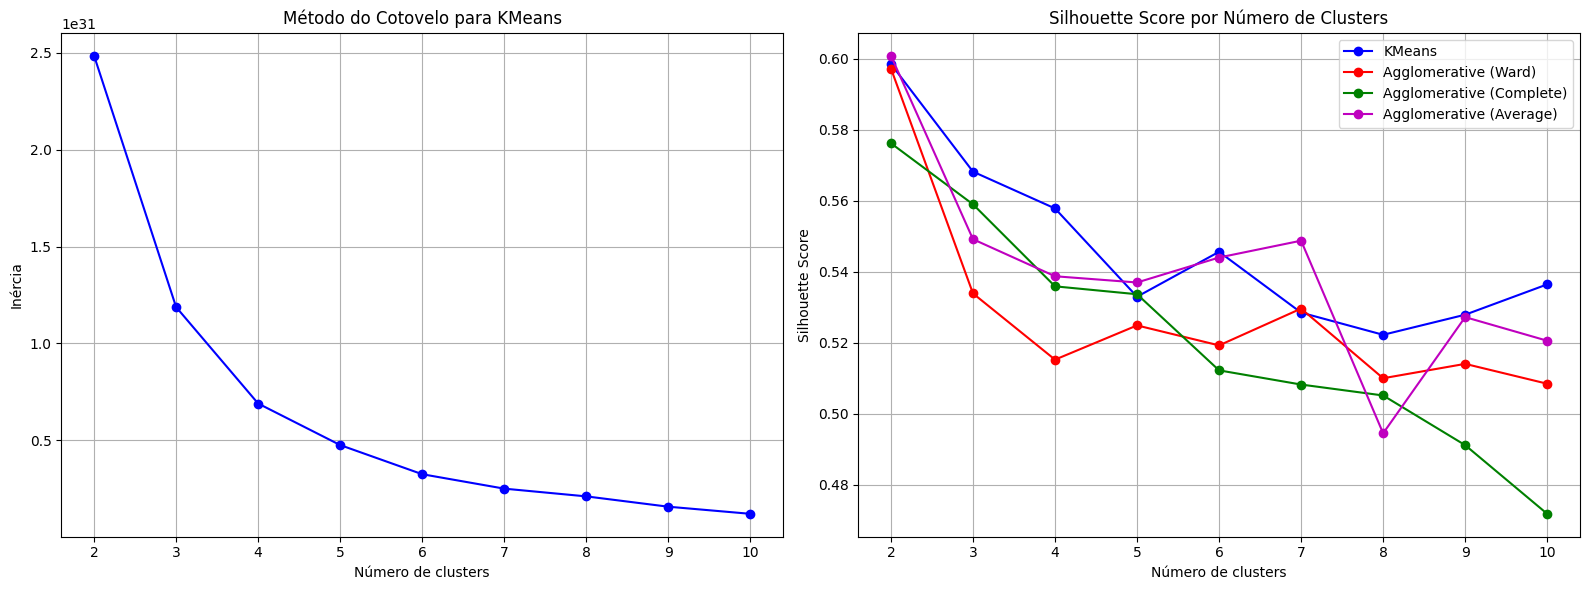

In [56]:
# Método do cotovelo para KMeans
inertia_values = []
silhouette_scores_kmeans = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_original)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(df_original, kmeans.labels_))

# Método do cotovelo para AgglomerativeClustering
silhouette_scores_ward = []
silhouette_scores_complete = []
silhouette_scores_average = []

# Testando em todos os algoritmos
for k in k_range:
    # Ward linkage
    agglo_ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    ward_labels = agglo_ward.fit_predict(df_original)
    silhouette_scores_ward.append(silhouette_score(df_original, ward_labels))
    
    # Complete linkage
    agglo_complete = AgglomerativeClustering(n_clusters=k, linkage='complete')
    complete_labels = agglo_complete.fit_predict(df_original)
    silhouette_scores_complete.append(silhouette_score(df_original, complete_labels))
    
    # Average linkage
    agglo_average = AgglomerativeClustering(n_clusters=k, linkage='average')
    average_labels = agglo_average.fit_predict(df_original)
    silhouette_scores_average.append(silhouette_score(df_original, average_labels))

# Plotando os resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Silhouette Score para todos os algoritmos
ax2.plot(k_range, silhouette_scores_kmeans, 'bo-', label='KMeans')
ax2.plot(k_range, silhouette_scores_ward, 'ro-', label='Agglomerative (Ward)')
ax2.plot(k_range, silhouette_scores_complete, 'go-', label='Agglomerative (Complete)')
ax2.plot(k_range, silhouette_scores_average, 'mo-', label='Agglomerative (Average)')
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por Número de Clusters')
ax2.legend()
ax2.grid(True)

# Gráfico da inércia para KMeans (método do cotovelo)
ax1.plot(k_range, inertia_values, 'bo-')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo para KMeans')
ax1.grid(True)

plt.tight_layout()
plt.show()


### Dados pré-processados

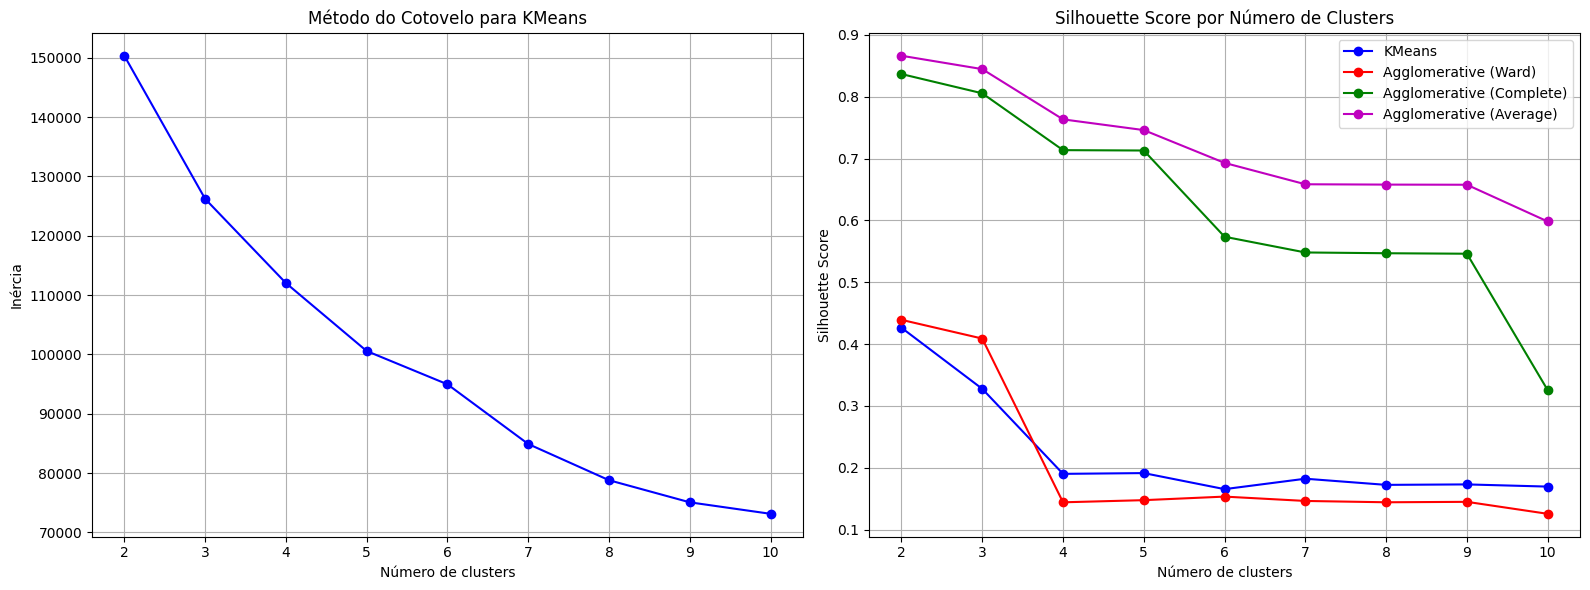

In [57]:
# Método do cotovelo para KMeans
inertia_values = []
silhouette_scores_kmeans = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_preprocessed)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(df_preprocessed, kmeans.labels_))

# Método do cotovelo para AgglomerativeClustering
silhouette_scores_ward = []
silhouette_scores_complete = []
silhouette_scores_average = []

# Testando em todos os algoritmos
for k in k_range:
    # Ward linkage
    agglo_ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    ward_labels = agglo_ward.fit_predict(df_preprocessed)
    silhouette_scores_ward.append(silhouette_score(df_preprocessed, ward_labels))
    
    # Complete linkage
    agglo_complete = AgglomerativeClustering(n_clusters=k, linkage='complete')
    complete_labels = agglo_complete.fit_predict(df_preprocessed)
    silhouette_scores_complete.append(silhouette_score(df_preprocessed, complete_labels))
    
    # Average linkage
    agglo_average = AgglomerativeClustering(n_clusters=k, linkage='average')
    average_labels = agglo_average.fit_predict(df_preprocessed)
    silhouette_scores_average.append(silhouette_score(df_preprocessed, average_labels))

# Plotando os resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Silhouette Score para todos os algoritmos
ax2.plot(k_range, silhouette_scores_kmeans, 'bo-', label='KMeans')
ax2.plot(k_range, silhouette_scores_ward, 'ro-', label='Agglomerative (Ward)')
ax2.plot(k_range, silhouette_scores_complete, 'go-', label='Agglomerative (Complete)')
ax2.plot(k_range, silhouette_scores_average, 'mo-', label='Agglomerative (Average)')
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por Número de Clusters')
ax2.legend()
ax2.grid(True)

# Gráfico da inércia para KMeans (método do cotovelo)
ax1.plot(k_range, inertia_values, 'bo-')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo para KMeans')
ax1.grid(True)

plt.tight_layout()
plt.show()


### Dados pré-processados com PCA

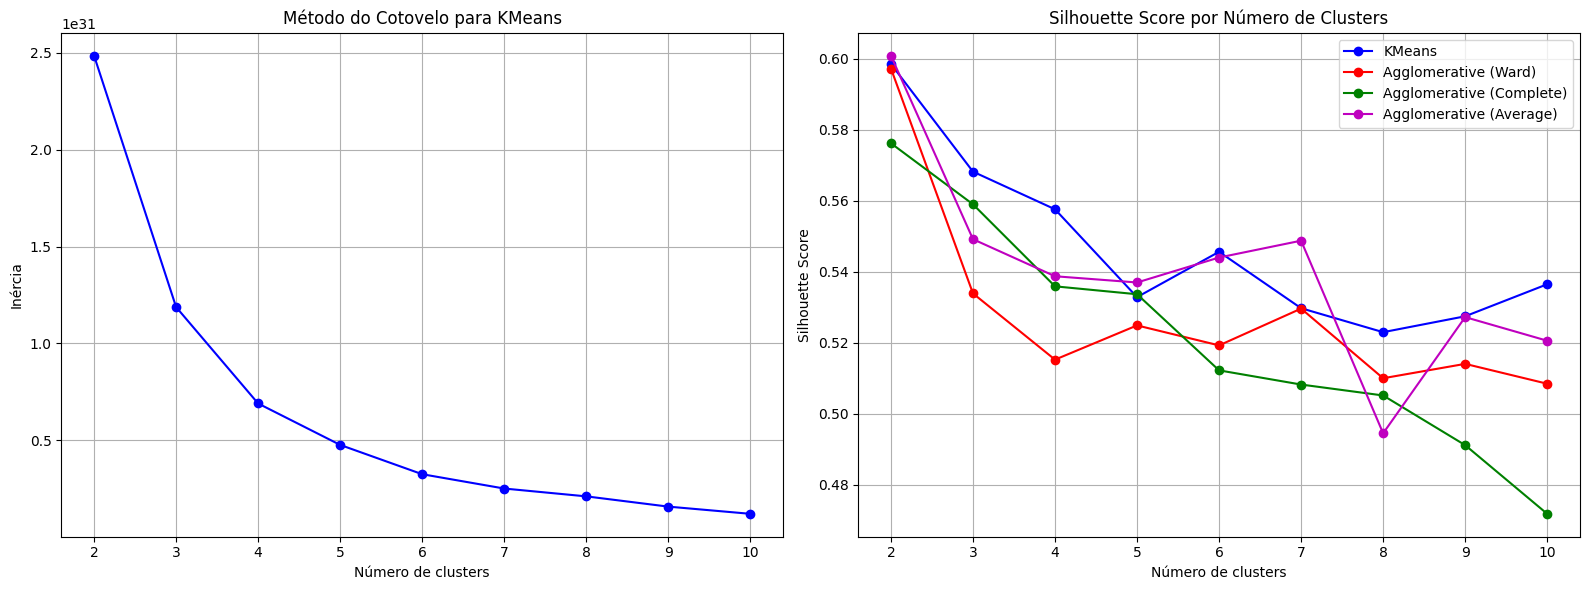

In [58]:
# Método do cotovelo para KMeans
inertia_values = []
silhouette_scores_kmeans = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_preprocessed_pca)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(df_preprocessed_pca, kmeans.labels_))

# Método do cotovelo para AgglomerativeClustering
silhouette_scores_ward = []
silhouette_scores_complete = []
silhouette_scores_average = []

# Testando em todos os algoritmos
for k in k_range:
    # Ward linkage
    agglo_ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    ward_labels = agglo_ward.fit_predict(df_preprocessed_pca)
    silhouette_scores_ward.append(silhouette_score(df_preprocessed_pca, ward_labels))
    
    # Complete linkage
    agglo_complete = AgglomerativeClustering(n_clusters=k, linkage='complete')
    complete_labels = agglo_complete.fit_predict(df_preprocessed_pca)
    silhouette_scores_complete.append(silhouette_score(df_preprocessed_pca, complete_labels))
    
    # Average linkage
    agglo_average = AgglomerativeClustering(n_clusters=k, linkage='average')
    average_labels = agglo_average.fit_predict(df_preprocessed_pca)
    silhouette_scores_average.append(silhouette_score(df_preprocessed_pca, average_labels))

# Plotando os resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Silhouette Score para todos os algoritmos
ax2.plot(k_range, silhouette_scores_kmeans, 'bo-', label='KMeans')
ax2.plot(k_range, silhouette_scores_ward, 'ro-', label='Agglomerative (Ward)')
ax2.plot(k_range, silhouette_scores_complete, 'go-', label='Agglomerative (Complete)')
ax2.plot(k_range, silhouette_scores_average, 'mo-', label='Agglomerative (Average)')
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por Número de Clusters')
ax2.legend()
ax2.grid(True)

# Gráfico da inércia para KMeans (método do cotovelo)
ax1.plot(k_range, inertia_values, 'bo-')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo para KMeans')
ax1.grid(True)

plt.tight_layout()
plt.show()

## Método do cotovelo
### Dados originais
Será usado o valor de K = 4 para o método aglomerativo e K = 5 para o método KMeans

### Dados pré-processados
Será usado o valor de K = 5 para o método aglomerativo e K = 6 para o método KMeans

### Dados pré-processados com PCA
Será usado o valor de K = 5 para o método aglomerativo e K = 6 para o método KMeans

### Dados originais

In [59]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)

# AgglomerativeClustering
agglo_ward = AgglomerativeClustering(n_clusters=5, linkage='ward')
agglo_complete = AgglomerativeClustering(n_clusters=5, linkage='complete')
agglo_average = AgglomerativeClustering(n_clusters=5, linkage='average')

In [60]:
# Realizando a predição
kmeans_pred = kmeans.fit_predict(df_original)
agglo_ward_pred = agglo_ward.fit_predict(df_original)
agglo_complete_pred = agglo_complete.fit_predict(df_original)
agglo_average_pred = agglo_average.fit_predict(df_original)

# Avaliando os modelos
print("KMeans:")
print(f"Silhouette Score: {silhouette_score(df_original, kmeans_pred)}")
print("\nAgglomerativeClustering (Ward):")
print(f"Silhouette Score: {silhouette_score(df_original, agglo_ward_pred)}")
print("\nAgglomerativeClustering (Complete):")
print(f"Silhouette Score: {silhouette_score(df_original, agglo_complete_pred)}")
print("\nAgglomerativeClustering (Average):")
print(f"Silhouette Score: {silhouette_score(df_original, agglo_average_pred)}")

KMeans:
Silhouette Score: 0.5578417077775135

AgglomerativeClustering (Ward):
Silhouette Score: 0.5248690121865374

AgglomerativeClustering (Complete):
Silhouette Score: 0.5336579952448389

AgglomerativeClustering (Average):
Silhouette Score: 0.5369702933796511


### Dados pré-processados

In [61]:
# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

# AgglomerativeClustering
agglo_ward = AgglomerativeClustering(n_clusters=6, linkage='ward')
agglo_complete = AgglomerativeClustering(n_clusters=6, linkage='complete')
agglo_average = AgglomerativeClustering(n_clusters=6, linkage='average')

# Realizando a predição
kmeans_pred = kmeans.fit_predict(df_preprocessed)
agglo_ward_pred = agglo_ward.fit_predict(df_preprocessed)
agglo_complete_pred = agglo_complete.fit_predict(df_preprocessed)
agglo_average_pred = agglo_average.fit_predict(df_preprocessed)

# Avaliando os modelos
print("KMeans:")
print(f"Silhouette Score: {silhouette_score(df_preprocessed, kmeans_pred)}")
print("\nAgglomerativeClustering (Ward):")
print(f"Silhouette Score: {silhouette_score(df_preprocessed, agglo_ward_pred)}")
print("\nAgglomerativeClustering (Complete):")
print(f"Silhouette Score: {silhouette_score(df_preprocessed, agglo_complete_pred)}")
print("\nAgglomerativeClustering (Average):")
print(f"Silhouette Score: {silhouette_score(df_preprocessed, agglo_average_pred)}")

KMeans:
Silhouette Score: 0.1913808139804527

AgglomerativeClustering (Ward):
Silhouette Score: 0.15336986635334915

AgglomerativeClustering (Complete):
Silhouette Score: 0.5735037970826238

AgglomerativeClustering (Average):
Silhouette Score: 0.6928997080899357


### Dados pré-processados com PCA

In [62]:
# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

# AgglomerativeClustering
agglo_ward = AgglomerativeClustering(n_clusters=6, linkage='ward')
agglo_complete = AgglomerativeClustering(n_clusters=6, linkage='complete')
agglo_average = AgglomerativeClustering(n_clusters=6, linkage='average')

# Realizando a predição
kmeans_pred = kmeans.fit_predict(df_preprocessed_pca)
agglo_ward_pred = agglo_ward.fit_predict(df_preprocessed_pca)
agglo_complete_pred = agglo_complete.fit_predict(df_preprocessed_pca)
agglo_average_pred = agglo_average.fit_predict(df_preprocessed_pca)

# Avaliando os modelos
print("KMeans:")
print(f"Silhouette Score: {silhouette_score(df_preprocessed_pca, kmeans_pred)}")
print("\nAgglomerativeClustering (Ward):")
print(f"Silhouette Score: {silhouette_score(df_preprocessed_pca, agglo_ward_pred)}")
print("\nAgglomerativeClustering (Complete):")
print(f"Silhouette Score: {silhouette_score(df_preprocessed_pca, agglo_complete_pred)}")
print("\nAgglomerativeClustering (Average):")
print(f"Silhouette Score: {silhouette_score(df_preprocessed_pca, agglo_average_pred)}")

KMeans:
Silhouette Score: 0.5328418069876888

AgglomerativeClustering (Ward):
Silhouette Score: 0.5192360401440129

AgglomerativeClustering (Complete):
Silhouette Score: 0.512199148557706

AgglomerativeClustering (Average):
Silhouette Score: 0.5440113068549556


# Resultados

### Os modelos agglomerativos foram mais eficientes que os modelos baseados em distância para esse problema, menos em um único caso, este sendo o dos dados sem pré-processamento algum.
A silhouette score dos modelos agglomerativos ficou na média de 52%, porém houve um caso em que a sua silhouette score foi de 69% nos dados com pré-processamento e sem PCA.

Modelos hierárquicos tendem a se beneficiar de pré-processamento e PCA, isso ficou evidente nos resultados obtidos.